In [ ]:
!pip install -q matplotlib numpy torch torchvision

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Categorical
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from IPython.display import clear_output
import time
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'🖥️  Using device: {device}')
print('✅ Setup complete!')

🖥️  Using device: cuda
✅ Setup complete!


In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
val_dataset   = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Small subset so each child network trains fast
train_subset = torch.utils.data.Subset(train_dataset, range(5000))
val_subset   = torch.utils.data.Subset(val_dataset,   range(1000))

train_loader = torch.utils.data.DataLoader(train_subset, batch_size=128, shuffle=True)
val_loader   = torch.utils.data.DataLoader(val_subset,   batch_size=256, shuffle=False)

print('✅ MNIST loaded!')
print('   Train subset: 5000 samples')
print('   Val   subset: 1000 samples')
print('   (Subsets keep child network training fast on CPU)')

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.59MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 134kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.27MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.84MB/s]

✅ MNIST loaded!
   Train subset: 5000 samples
   Val   subset: 1000 samples
   (Subsets keep child network training fast on CPU)


In [ ]:
# The RL agent will choose between these options for each decision
SEARCH_SPACE = {
    'num_layers':   [2, 3, 4],
    'hidden_size':  [32, 64, 128, 256],
    'activation':   ['relu', 'tanh', 'gelu', 'leaky_relu'],
    'dropout_rate': [0.0, 0.1, 0.3, 0.5]
}

NUM_LAYERS_CHOICES  = len(SEARCH_SPACE['num_layers'])    # 3
HIDDEN_SIZE_CHOICES = len(SEARCH_SPACE['hidden_size'])   # 4
ACTIVATION_CHOICES  = len(SEARCH_SPACE['activation'])    # 4
DROPOUT_CHOICES     = len(SEARCH_SPACE['dropout_rate'])  # 4

VOCAB_SIZE    = max(NUM_LAYERS_CHOICES, HIDDEN_SIZE_CHOICES, ACTIVATION_CHOICES, DROPOUT_CHOICES)
NUM_DECISIONS = 4  # agent makes 4 decisions per architecture

total_archs = NUM_LAYERS_CHOICES * HIDDEN_SIZE_CHOICES * ACTIVATION_CHOICES * DROPOUT_CHOICES

print('🔍 Architecture Search Space:')
for key, vals in SEARCH_SPACE.items():
    print(f'   {key}: {vals}')
print(f'\n📊 Total possible architectures: {total_archs}')
print('   The RL agent will learn to find the best ones!')

🔍 Architecture Search Space:
   num_layers: [2, 3, 4]
   hidden_size: [32, 64, 128, 256]
   activation: ['relu', 'tanh', 'gelu', 'leaky_relu']
   dropout_rate: [0.0, 0.1, 0.3, 0.5]

📊 Total possible architectures: 192
   The RL agent will learn to find the best ones!


In [ ]:
class ControllerRNN(nn.Module):
    """
    The RL Agent — an LSTM that sequentially samples
    architectural decisions as discrete tokens.
    Inspired by: Zoph & Le, Google Brain, ICLR 2017.
    """
    def __init__(self, hidden_size=64):
        super().__init__()
        self.hidden_size = hidden_size

        # LSTM makes one decision at a time
        self.lstm = nn.LSTMCell(hidden_size, hidden_size)

        # One output head per architectural decision
        self.decision_heads = nn.ModuleList([
            nn.Linear(hidden_size, NUM_LAYERS_CHOICES),
            nn.Linear(hidden_size, HIDDEN_SIZE_CHOICES),
            nn.Linear(hidden_size, ACTIVATION_CHOICES),
            nn.Linear(hidden_size, DROPOUT_CHOICES),
        ])

        # Embeds previous action to feed back into LSTM
        self.embed = nn.Embedding(VOCAB_SIZE + 1, hidden_size)

    def forward(self):
        """
        Sample one architecture.
        Returns actions, log_probs, entropies.
        """
        h = torch.zeros(1, self.hidden_size).to(device)
        c = torch.zeros(1, self.hidden_size).to(device)

        # Start token (special index = VOCAB_SIZE)
        inp = self.embed(torch.tensor([VOCAB_SIZE]).to(device))

        actions, log_probs, entropies = [], [], []

        for i in range(NUM_DECISIONS):
            h, c   = self.lstm(inp, (h, c))
            logits = self.decision_heads[i](h)
            dist   = Categorical(logits=logits)
            action = dist.sample()

            actions.append(action.item())
            log_probs.append(dist.log_prob(action))
            entropies.append(dist.entropy())

            # Feed chosen action back as next input
            inp = self.embed(action)

        return actions, log_probs, entropies


def decode_architecture(actions):
    """Convert action indices → readable architecture dict."""
    return {
        'num_layers':   SEARCH_SPACE['num_layers'][actions[0]],
        'hidden_size':  SEARCH_SPACE['hidden_size'][actions[1]],
        'activation':   SEARCH_SPACE['activation'][actions[2]],
        'dropout_rate': SEARCH_SPACE['dropout_rate'][actions[3]],
    }

print('✅ Controller RNN defined!')
print('   LSTM hidden size: 64')
print('   Decisions: [num_layers, hidden_size, activation, dropout]')
print('   Each decision feeds back as input to the next step')

✅ Controller RNN defined!
   LSTM hidden size: 64
   Decisions: [num_layers, hidden_size, activation, dropout]
   Each decision feeds back as input to the next step


In [ ]:
def build_child_network(arch):
    """
    Dynamically build an MLP from the architecture dict.
    Input: 784 (MNIST flattened) → Output: 10 (digit classes)
    """
    layers = [nn.Flatten()]
    in_features = 784

    for _ in range(arch['num_layers']):
        layers.append(nn.Linear(in_features, arch['hidden_size']))
        layers.append(nn.BatchNorm1d(arch['hidden_size']))

        act = arch['activation']
        if act == 'relu':       layers.append(nn.ReLU())
        elif act == 'tanh':     layers.append(nn.Tanh())
        elif act == 'gelu':     layers.append(nn.GELU())
        elif act == 'leaky_relu': layers.append(nn.LeakyReLU())

        if arch['dropout_rate'] > 0:
            layers.append(nn.Dropout(arch['dropout_rate']))

        in_features = arch['hidden_size']

    layers.append(nn.Linear(in_features, 10))
    return nn.Sequential(*layers).to(device)


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def train_and_evaluate(arch, epochs=3):
    """
    Train a child network for a few epochs.
    Returns (val_accuracy, param_count).
    Val accuracy = REWARD for the RL agent.
    """
    model     = build_child_network(arch)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    # Quick training
    model.train()
    for _ in range(epochs):
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()

    # Evaluate
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            preds = model(x).argmax(dim=1)
            correct += (preds == y).sum().item()
            total   += y.size(0)

    return correct / total, count_params(model)


# Quick sanity check
test_arch = {'num_layers': 2, 'hidden_size': 64, 'activation': 'relu', 'dropout_rate': 0.1}
test_model = build_child_network(test_arch)
print('✅ Child network builder ready!')
print(f'   Test arch params: {count_params(test_model):,}')
print(f'   Test arch: {test_arch}')

✅ Child network builder ready!
   Test arch params: 55,306
   Test arch: {'num_layers': 2, 'hidden_size': 64, 'activation': 'relu', 'dropout_rate': 0.1}


In [ ]:
plt.style.use('dark_background')

def visualize(episode, history, arch, reward, n_params, best_reward, best_arch):
    clear_output(wait=True)

    fig = plt.figure(figsize=(18, 10), facecolor='#0D1117')
    fig.suptitle(
        f'🧠 Neural Architecture Search with RL  —  Episode {episode+1}',
        fontsize=15, color='white', fontweight='bold'
    )
    gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)
    episodes = list(range(1, len(history['rewards']) + 1))

    def style_ax(ax):
        ax.set_facecolor('#161B22')
        for spine in ax.spines.values():
            spine.set_edgecolor('#333')
        ax.tick_params(colors='#666')

    # ── Plot 1: Reward curve ──────────────────────────────────
    ax1 = fig.add_subplot(gs[0, 0])
    style_ax(ax1)
    ax1.plot(episodes, history['rewards'],   color='#00FF88', lw=2.5, label='Val Acc (reward)')
    ax1.plot(episodes, history['baseline'],  color='#FF6B35', lw=2, ls='--', label='Baseline (EMA)')
    ax1.plot(episodes, history['best'],      color='#FFD700', lw=1.5, ls=':', label='Best so far')
    ax1.fill_between(episodes, history['rewards'], history['baseline'],
                     where=[r > b for r, b in zip(history['rewards'], history['baseline'])],
                     alpha=0.12, color='#00FF88')
    ax1.set_title('📈 Reward over Episodes', color='white', fontsize=10)
    ax1.set_xlabel('Episode', color='#888'); ax1.set_ylabel('Val Accuracy', color='#888')
    ax1.set_ylim(0, 1.05); ax1.legend(fontsize=7)

    # ── Plot 2: Policy loss ───────────────────────────────────
    ax2 = fig.add_subplot(gs[0, 1])
    style_ax(ax2)
    ax2.plot(episodes, history['loss'], color='#FF4466', lw=2.5)
    ax2.fill_between(episodes, history['loss'], alpha=0.1, color='#FF4466')
    ax2.set_title('📉 Controller Policy Loss', color='white', fontsize=10)
    ax2.set_xlabel('Episode', color='#888'); ax2.set_ylabel('Loss', color='#888')

    # ── Plot 3: Params vs reward scatter ──────────────────────
    ax3 = fig.add_subplot(gs[0, 2])
    style_ax(ax3)
    sc = ax3.scatter([p/1000 for p in history['params']],
                     history['rewards'],
                     c=episodes, cmap='plasma', s=60, alpha=0.85, edgecolors='white', lw=0.4)
    plt.colorbar(sc, ax=ax3, label='Episode').ax.yaxis.label.set_color('white')
    ax3.set_title('🔢 Param Count vs Accuracy', color='white', fontsize=10)
    ax3.set_xlabel('Params (K)', color='#888'); ax3.set_ylabel('Val Accuracy', color='#888')

    # ── Plot 4: Layer choice distribution ────────────────────
    ax4 = fig.add_subplot(gs[1, 0])
    style_ax(ax4)
    vals, cnts = np.unique(history['layers'], return_counts=True)
    ax4.bar([str(SEARCH_SPACE['num_layers'][v]) for v in vals], cnts,
            color='#00FF88', alpha=0.8, edgecolor='#333')
    ax4.set_title("🏗️  Agent's Layer Choices", color='white', fontsize=10)
    ax4.set_xlabel('Num Layers', color='#888'); ax4.set_ylabel('Times Chosen', color='#888')

    # ── Plot 5: Hidden size distribution ─────────────────────
    ax5 = fig.add_subplot(gs[1, 1])
    style_ax(ax5)
    vals, cnts = np.unique(history['hiddens'], return_counts=True)
    ax5.bar([str(SEARCH_SPACE['hidden_size'][v]) for v in vals], cnts,
            color='#66AAFF', alpha=0.8, edgecolor='#333')
    ax5.set_title("🧩 Agent's Hidden Size Choices", color='white', fontsize=10)
    ax5.set_xlabel('Hidden Size', color='#888'); ax5.set_ylabel('Times Chosen', color='#888')

    # ── Plot 6: Current + best arch info ─────────────────────
    ax6 = fig.add_subplot(gs[1, 2])
    style_ax(ax6); ax6.axis('off')
    info = (
        f"CURRENT EPISODE\n{'─'*26}\n"
        f"  Layers:      {arch['num_layers']}\n"
        f"  Hidden Size: {arch['hidden_size']}\n"
        f"  Activation:  {arch['activation']}\n"
        f"  Dropout:     {arch['dropout_rate']}\n"
        f"  Accuracy:    {reward*100:.2f}%\n"
        f"  Params:      {n_params:,}\n\n"
        f"BEST SO FAR\n{'─'*26}\n"
    )
    if best_arch:
        info += (
            f"  Layers:      {best_arch['num_layers']}\n"
            f"  Hidden Size: {best_arch['hidden_size']}\n"
            f"  Activation:  {best_arch['activation']}\n"
            f"  Dropout:     {best_arch['dropout_rate']}\n"
            f"  Best Acc:    {best_reward*100:.2f}%\n"
        )
    ax6.text(0.05, 0.97, info, transform=ax6.transAxes,
             fontsize=9.5, color='#EEEEEE', verticalalignment='top',
             fontfamily='monospace',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='#1F2937', edgecolor='#374151'))
    ax6.set_title('📋 Architecture Details', color='white', fontsize=10)

    plt.savefig('/tmp/nas_live.png', dpi=75, bbox_inches='tight', facecolor='#0D1117')
    plt.show()

print('✅ Visualization ready!')

✅ Visualization ready!


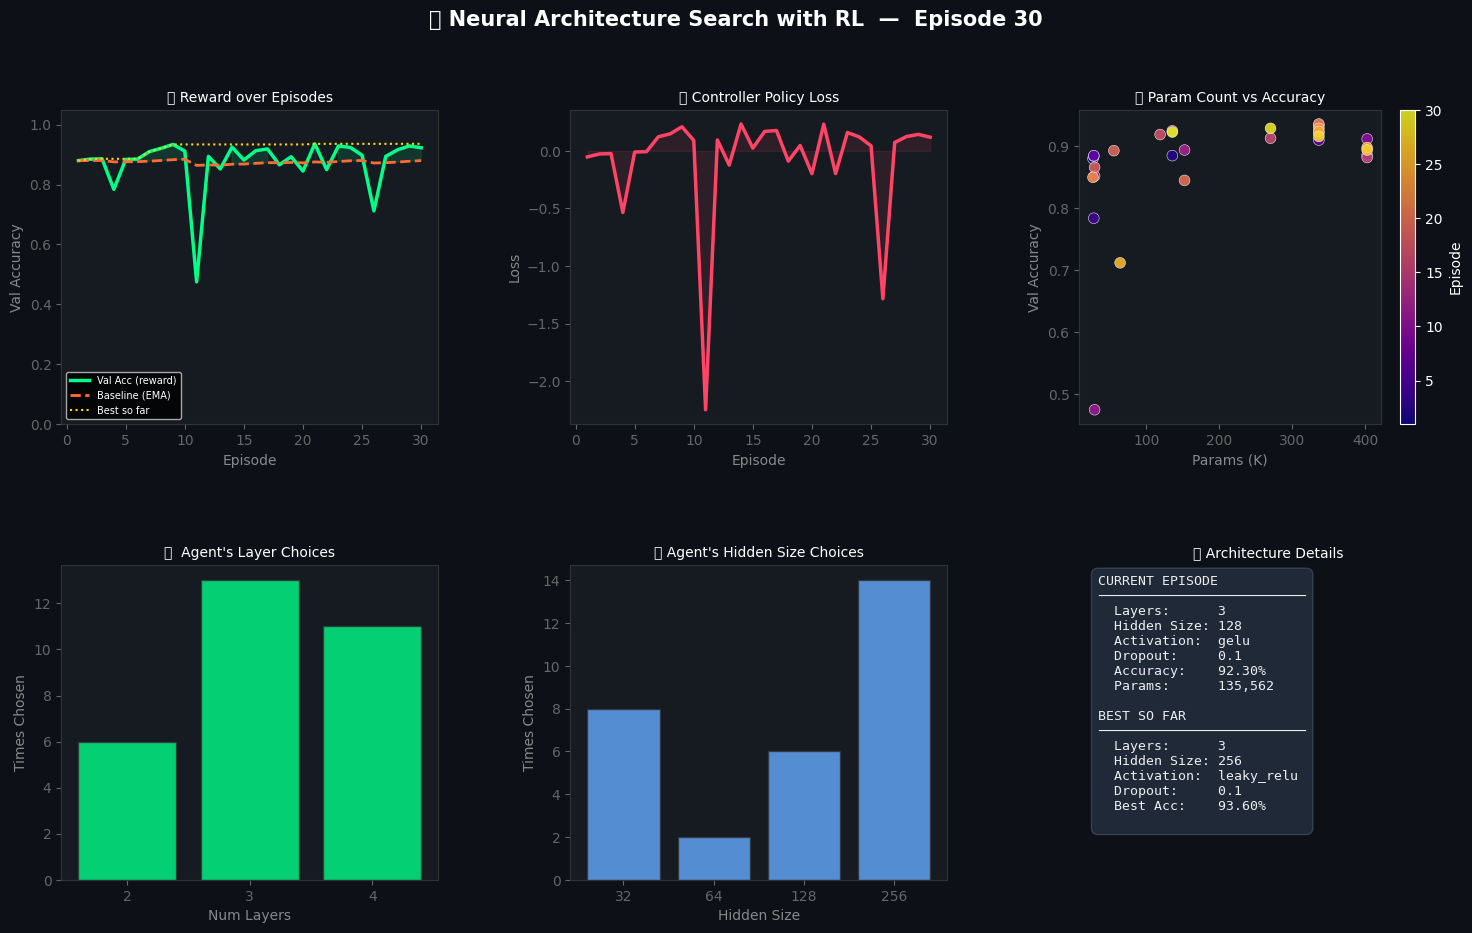

  Ep  30 | Reward: 0.9230 | Best: 0.9360 | 2.4min elapsed

🏆 NAS COMPLETE!
   Best Val Accuracy : 93.60%
   Best Architecture : {'num_layers': 3, 'hidden_size': 256, 'activation': 'leaky_relu', 'dropout_rate': 0.1}
   Total Time        : 2.4 minutes


In [ ]:
# ── Hyperparameters ───────────────────────────────────────────
NUM_EPISODES   = 30      # architectures to try
CHILD_EPOCHS   = 3       # training epochs per child
CONTROLLER_LR  = 3e-3
ENTROPY_COEFF  = 0.01    # exploration bonus
BASELINE_DECAY = 0.95    # EMA decay for baseline
# ─────────────────────────────────────────────────────────────

controller     = ControllerRNN(hidden_size=64).to(device)
ctrl_optimizer = optim.Adam(controller.parameters(), lr=CONTROLLER_LR)

history = {
    'rewards': [], 'baseline': [], 'best': [],
    'loss': [], 'params': [],
    'layers': [], 'hiddens': [], 'acts': [], 'drops': []
}

baseline    = 0.0
best_reward = 0.0
best_arch   = None
start_time  = time.time()

print('🚀 Starting NAS with REINFORCE...\n')
print(f'   Episodes:      {NUM_EPISODES}')
print(f'   Child epochs:  {CHILD_EPOCHS}')
print(f'   Controller LR: {CONTROLLER_LR}')
print(f'   Entropy coeff: {ENTROPY_COEFF}  ← encourages exploration')
print()

for episode in range(NUM_EPISODES):

    # STEP 1: Controller samples an architecture
    controller.train()
    actions, log_probs, entropies = controller()
    arch = decode_architecture(actions)

    # STEP 2: Build + train child network → get reward
    print(f'  Ep {episode+1:3d} | Arch: {arch} | Training...', end='\r')
    reward, n_params = train_and_evaluate(arch, epochs=CHILD_EPOCHS)

    # STEP 3: Update baseline (reduces gradient variance)
    if episode == 0:
        baseline = reward
    else:
        baseline = BASELINE_DECAY * baseline + (1 - BASELINE_DECAY) * reward

    advantage = reward - baseline  # positive = better than avg

    if reward > best_reward:
        best_reward = reward
        best_arch   = arch.copy()

    # STEP 4: REINFORCE policy gradient update
    # Maximize: E[advantage * log_prob] + entropy_bonus
    ctrl_optimizer.zero_grad()

    policy_loss  = -sum(lp * advantage for lp in log_probs)
    entropy_loss = -ENTROPY_COEFF * sum(entropies)   # exploration
    total_loss   = policy_loss + entropy_loss

    total_loss.backward()
    torch.nn.utils.clip_grad_norm_(controller.parameters(), 5.0)
    ctrl_optimizer.step()

    # STEP 5: Record
    history['rewards'].append(reward)
    history['baseline'].append(baseline)
    history['best'].append(best_reward)
    history['loss'].append(total_loss.item())
    history['params'].append(n_params)
    history['layers'].append(actions[0])
    history['hiddens'].append(actions[1])
    history['acts'].append(actions[2])
    history['drops'].append(actions[3])

    # STEP 6: Live plot update
    visualize(episode, history, arch, reward, n_params, best_reward, best_arch)
    elapsed = (time.time() - start_time) / 60
    print(f'  Ep {episode+1:3d} | Reward: {reward:.4f} | Best: {best_reward:.4f} | {elapsed:.1f}min elapsed')

print('\n' + '='*55)
print('🏆 NAS COMPLETE!')
print(f'   Best Val Accuracy : {best_reward*100:.2f}%')
print(f'   Best Architecture : {best_arch}')
print(f'   Total Time        : {(time.time()-start_time)/60:.1f} minutes')
print('='*55)

In [ ]:
print(f'🏗️  Training best RL-discovered architecture...')
print(f'   {best_arch}\n')

full_train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=128, shuffle=True)
full_val_loader   = torch.utils.data.DataLoader(val_dataset,   batch_size=256, shuffle=False)

best_model    = build_child_network(best_arch)
best_opt      = optim.Adam(best_model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler     = optim.lr_scheduler.CosineAnnealingLR(best_opt, T_max=15)
criterion     = nn.CrossEntropyLoss()

FULL_EPOCHS    = 15
train_losses   = []
val_accs       = []

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), facecolor='#0D1117')

for epoch in range(FULL_EPOCHS):
    # Train
    best_model.train()
    epoch_loss = 0
    for x, y in full_train_loader:
        x, y = x.to(device), y.to(device)
        best_opt.zero_grad()
        loss = criterion(best_model(x), y)
        loss.backward()
        best_opt.step()
        epoch_loss += loss.item()
    scheduler.step()

    # Eval
    best_model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in full_val_loader:
            x, y = x.to(device), y.to(device)
            preds = best_model(x).argmax(dim=1)
            correct += (preds == y).sum().item()
            total   += y.size(0)

    train_losses.append(epoch_loss / len(full_train_loader))
    val_accs.append(correct / total)

    # Live plot
    clear_output(wait=True)
    ep_range = list(range(1, epoch + 2))

    for ax in [ax1, ax2]:
        ax.clear()
        ax.set_facecolor('#161B22')
        for spine in ax.spines.values(): spine.set_edgecolor('#333')
        ax.tick_params(colors='#888')

    ax1.plot(ep_range, train_losses, color='#FF4466', lw=2.5)
    ax1.fill_between(ep_range, train_losses, alpha=0.12, color='#FF4466')
    ax1.set_title('Training Loss', color='white', fontsize=12)
    ax1.set_xlabel('Epoch', color='#888'); ax1.set_ylabel('CE Loss', color='#888')

    ax2.plot(ep_range, [a*100 for a in val_accs], color='#00FF88', lw=2.5)
    ax2.fill_between(ep_range, [a*100 for a in val_accs], alpha=0.12, color='#00FF88')
    ax2.axhline(max([a*100 for a in val_accs]), color='#FFD700', lw=1.2, ls='--')
    ax2.set_title(f'Val Accuracy — Best: {max(val_accs)*100:.2f}%', color='white', fontsize=12)
    ax2.set_xlabel('Epoch', color='#888'); ax2.set_ylabel('Accuracy (%)', color='#888')
    ax2.set_ylim(80, 100)

    fig.suptitle(
        f'🏆 Best RL-Discovered Architecture — Epoch {epoch+1}/{FULL_EPOCHS}  |  {best_arch}',
        color='white', fontsize=11, fontweight='bold'
    )
    fig.patch.set_facecolor('#0D1117')
    plt.tight_layout()
    plt.show()

    print(f'  Epoch {epoch+1:2d}/{FULL_EPOCHS} | Loss: {train_losses[-1]:.4f} | Val Acc: {val_accs[-1]*100:.2f}%')

print(f'\n✅ Final Accuracy: {max(val_accs)*100:.2f}%')
print(f'   Architecture: {best_arch}')
print(f'   Parameters:   {count_params(best_model):,}')

<Figure size 640x480 with 0 Axes>

  Epoch 15/15 | Loss: 0.0067 | Val Acc: 98.62%

✅ Final Accuracy: 98.65%
   Architecture: {'num_layers': 3, 'hidden_size': 256, 'activation': 'leaky_relu', 'dropout_rate': 0.1}
   Parameters:   336,650
